<a href="https://colab.research.google.com/github/Nahom32/Resonance-Experiments/blob/main/Dairy/genCowExperiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision pytorchvideo decord

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 15.8 MB/s eta 0:00:00
  Created wheel for pytorchvideo: filename=pytorchvideo-0.1.5-py3-none-any.whl size=188686 sha256=0ffd56d4dd20a9d0c24ac4136299f0d09202ce39a076023028a1bfa4050cf4eb
  Stored in directory: /root/.cache/pip/wheels/b3/49/dc/aab2dce83e38b59849db13a4f4ddd220e568e24b58332fb0f9
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=d92121dcb53ffd9d967c0d0acf2006011dbc11a6485ab52a933889671e1dff6f
  Stored in directory: /root/.cache/pip/wheel

In [ ]:
!pip install opencv-python tqdm pandas

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("fandaoerji/cbvd-5cow-behavior-video-dataset")
print(path)
import os

for d in os.listdir(path):
    print(d)

100%|██████████| 10.8G/10.8G [01:49<00:00, 106MB/s]

Extracting files...


In [ ]:
import os


print("Dataset root path:", path)


print("\nDataset structure preview:")
for root, dirs, files in os.walk(path):
    if files:
        rel = os.path.relpath(root, path)
        print(f"{rel}/  → {len(files)} files (first 3: {files[:3]})")


DATA_ROOT = path
ANNOTATIONS_DIR = os.path.join(path, "annotations")
VIDEO_DIR = os.path.join(path, "video_cut")
RAWFRAMES_DIR = os.path.join(path, "rawframes")

print(f"\n Paths ready:")
print(f"   DATA_ROOT       = {DATA_ROOT}")
print(f"   ANNOTATIONS_DIR = {ANNOTATIONS_DIR}")
print(f"   VIDEO_DIR       = {VIDEO_DIR}")

Dataset root path: /root/.cache/kagglehub/datasets/fandaoerji/cbvd-5cow-behavior-video-dataset/versions/11

Dataset structure preview:
./  → 1 files (first 3: ['CBVD-5.csv'])
minilabelframes/  → 4122 files (first 3: ['577_00005.jpg', '159_00004.jpg', '596_00007.jpg'])
rawframes_mini/110/  → 300 files (first 3: ['img_00287.jpg', 'img_00278.jpg', 'img_00196.jpg'])
rawframes_mini/295/  → 300 files (first 3: ['img_00287.jpg', 'img_00278.jpg', 'img_00196.jpg'])
rawframes_mini/281/  → 300 files (first 3: ['img_00287.jpg', 'img_00278.jpg', 'img_00196.jpg'])
rawframes_mini/260/  → 300 files (first 3: ['img_00287.jpg', 'img_00278.jpg', 'img_00196.jpg'])
rawframes_mini/686/  → 300 files (first 3: ['img_00287.jpg', 'img_00278.jpg', 'img_00196.jpg'])
rawframes_mini/533/  → 300 files (first 3: ['img_00287.jpg', 'img_00278.jpg', 'img_00196.jpg'])
rawframes_mini/578/  → 300 files (first 3: ['img_00287.jpg', 'img_00278.jpg', 'img_00196.jpg'])
rawframes_mini/602/  → 300 files (first 3: ['img_00287.jpg'

In [ ]:
DATA_ROOT = path

ANNOTATIONS_DIR = os.path.join(DATA_ROOT, "miniannotations")
FRAMES_DIR = os.path.join(DATA_ROOT, "rawframes_mini")

print(os.listdir(ANNOTATIONS_DIR))
ann_file = None

# Prioritize 'ava_train_v2.1.csv' as it seems to contain actual data
if 'ava_train_v2.1.csv' in os.listdir(ANNOTATIONS_DIR):
    ann_file = os.path.join(ANNOTATIONS_DIR, 'ava_train_v2.1.csv')
else:
    for f in os.listdir(ANNOTATIONS_DIR):
        if f.endswith(".csv"):
            ann_file = os.path.join(ANNOTATIONS_DIR, f)
            break
print("Using:", ann_file)

['ava_train_excluded_timestamps_v2.1.csv', 'ava_test_excluded_timestamps_v2.1.csv', 'ava_action_list_v2.1_for_activitynet_2018.pbtxt', 'ava_dense_proposals_val.FAIR.recall_93.9.pkl', 'ava_val_v2.1.csv', 'ava_val_excluded_timestamps_v2.1.csv', 'labelmap.txt', 'ava_dense_proposals_test.FAIR.recall_93.9.pkl', 'ava_dense_proposals_train.FAIR.recall_93.9.pkl', 'ava_train_v2.1.csv', 'ava_test_v2.1.csv']
Using: /root/.cache/kagglehub/datasets/fandaoerji/cbvd-5cow-behavior-video-dataset/versions/11/miniannotations/ava_train_v2.1.csv


In [ ]:
import pandas as pd

df = pd.read_csv(ann_file, header=None, dtype={0: str})

df.columns = [
    "video_id",
    "timestamp",
    "x1", "y1", "x2", "y2",
    "action_id",
    "target_id"
]

print(df.head())
print("Total samples:", len(df))

  video_id  timestamp        x1        y1        x2        y2  action_id  \
0      618          2  0.457031  0.355469  0.621094  0.675781          1   
1      618          2  0.457031  0.355469  0.621094  0.675781          5   
2      618          2  0.789062  0.488281  0.894531  0.828125          2   
3      618          2  0.789062  0.488281  0.894531  0.828125          5   
4      618          2  0.210938  0.332031  0.335938  0.582031          1   

   target_id  
0          1  
1          1  
2          1  
3          1  
4          1  
Total samples: 34102


In [ ]:
import os

print("Sample frame folders:")
print(os.listdir(FRAMES_DIR)[:20])
print("Sample video_ids from annotations:")
print(df["video_id"].head(20).tolist())

Sample frame folders:
['70', '46', '394', '222', '651', '161', '301', '490', '637', '364', '176', '141', '440', '668', '101', '377', '250', '184', '400', '383']
Sample video_ids from annotations:
['618', '618', '618', '618', '618', '618', '618', '618', '618', '618', '618', '621', '621', '621', '621', '621', '621', '621', '621', '621']


In [ ]:
valid_ids = set(os.listdir(FRAMES_DIR))

print("Number of frame folders:", len(valid_ids))

Number of frame folders: 686


In [ ]:
df["video_id"] = df["video_id"].apply(lambda x: str(int(x)))

df = df[df["video_id"].isin(valid_ids)]

print("Filtered dataset size:", len(df))

Filtered dataset size: 34025


In [ ]:
import torch
from torch.utils.data import Dataset
import os, cv2, random
import numpy as np

class CowDatasetHybrid(Dataset):
    def __init__(self, df, frames_dir, normal_classes, num_frames=8, fps=25):
        self.df = df.reset_index(drop=True)
        self.frames_dir = frames_dir
        self.num_frames = num_frames
        self.fps = fps

        self.normal_df = self.df[self.df["action_id"].isin([c+1 for c in normal_classes])]
        self.anomaly_df = self.df[~self.df["action_id"].isin([c+1 for c in normal_classes])]

    def __len__(self):
        return len(self.normal_df)

    def _load_clip(self, row):
        video_id = str(int(row.video_id))
        video_folder = os.path.join(self.frames_dir, video_id)

        if not os.path.exists(video_folder):
            return torch.zeros((self.num_frames, 3, 224, 224))

        frame_files = sorted(os.listdir(video_folder))
        if len(frame_files) == 0:
            return torch.zeros((self.num_frames, 3, 224, 224))

        center_idx = int(row.timestamp * self.fps)
        center_idx = min(max(center_idx, 0), len(frame_files)-1)

        start = max(0, center_idx - self.num_frames // 2)
        selected = frame_files[start:start+self.num_frames]

        frames = []
        for f in selected:
            img = cv2.imread(os.path.join(video_folder, f))
            if img is None:
                continue

            h, w, _ = img.shape
            x1 = int(row.x1 * w)
            y1 = int(row.y1 * h)
            x2 = int(row.x2 * w)
            y2 = int(row.y2 * h)

            x1, y1 = max(0,x1), max(0,y1)
            x2, y2 = min(w,x2), min(h,y2)

            if x2 <= x1 or y2 <= y1:
                continue

            img = img[y1:y2, x1:x2]
            img = cv2.resize(img, (224, 224))

            img = img / 255.0
            img = (img - 0.5) / 0.5

            frames.append(img)

        if len(frames) == 0:
            frames = [np.zeros((224,224,3))]*self.num_frames

        if len(frames) < self.num_frames:
            frames += [frames[-1]]*(self.num_frames-len(frames))

        frames = torch.tensor(frames).permute(0,3,1,2).float()
        return frames

    def __getitem__(self, idx):
        normal_row = self.normal_df.iloc[idx]
        normal_clip = self._load_clip(normal_row)

        # pseudo anomaly: sample from anomaly set
        pseudo_row = self.anomaly_df.sample(1).iloc[0]
        pseudo_clip = self._load_clip(pseudo_row)

        return normal_clip, pseudo_clip

In [ ]:
import torch.nn as nn
import torchvision.models as models

class HybridModel(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()

        base = models.resnet18(pretrained=True)
        self.encoder = nn.Sequential(*list(base.children())[:-1])  # 512

        self.projector = nn.Sequential(
            nn.Linear(512, latent_dim),
            nn.ReLU(),
            nn.Linear(latent_dim, latent_dim)
        )

        self.reconstructor = nn.Sequential(
            nn.Linear(latent_dim, latent_dim),
            nn.ReLU(),
            nn.Linear(latent_dim, 512)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)

        z = self.encoder(x).view(B, T, 512)
        z = z.mean(dim=1)

        z_proj = self.projector(z)
        z_rec  = self.reconstructor(z_proj)

        return z, z_proj, z_rec

In [ ]:
def reconstruction_loss(z, z_rec):
    return ((z - z_rec) ** 2).mean()

In [ ]:
def contrastive_loss(z_normal, z_pseudo, margin=1.0):
    dist = torch.norm(z_normal - z_pseudo, dim=1)
    loss = torch.clamp(margin - dist, min=0.0)
    return loss.mean()

In [ ]:
def hybrid_loss(z, z_rec, z_normal_proj, z_pseudo_proj, lambda_dist=0.5):
    L_rec = reconstruction_loss(z, z_rec)
    L_dist = contrastive_loss(z_normal_proj, z_pseudo_proj)

    return L_rec + lambda_dist * L_dist, L_rec, L_dist

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

history = {
    "total": [],
    "rec": [],
    "dist": []
}

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

In [ ]:
from torch.utils.data import DataLoader
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

dataset = CowDatasetHybrid(df, FRAMES_DIR, normal_classes=[0,1])
loader = DataLoader(dataset, batch_size=4, shuffle=True)

model = HybridModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s]


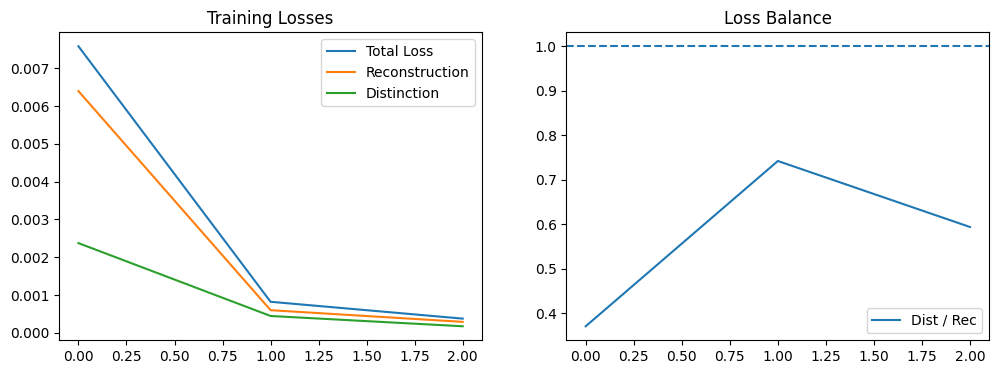

Epoch 3: Total=0.0004, Rec=0.0003, Dist=0.0002


KeyboardInterrupt: 

In [26]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()

    epoch_total = 0
    epoch_rec = 0
    epoch_dist = 0

    for normal_clip, pseudo_clip in loader:
        normal_clip = normal_clip.to(device)
        pseudo_clip = pseudo_clip.to(device)

        z_n, z_n_proj, z_n_rec = model(normal_clip)
        z_p, z_p_proj, _ = model(pseudo_clip)

        loss, L_rec, L_dist = hybrid_loss(
            z_n, z_n_rec,
            z_n_proj, z_p_proj
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_total += loss.item()
        epoch_rec += L_rec.item()
        epoch_dist += L_dist.item()

    # averages
    epoch_total /= len(loader)
    epoch_rec /= len(loader)
    epoch_dist /= len(loader)

    history["total"].append(epoch_total)
    history["rec"].append(epoch_rec)
    history["dist"].append(epoch_dist)

    # 🔥 LIVE PLOT
    clear_output(wait=True)

    plt.figure(figsize=(12,4))

    # Loss plot
    plt.subplot(1,2,1)
    plt.plot(history["total"], label="Total Loss")
    plt.plot(history["rec"], label="Reconstruction")
    plt.plot(history["dist"], label="Distinction")
    plt.legend()
    plt.title("Training Losses")

    # Ratio plot (VERY useful)
    plt.subplot(1,2,2)
    ratio = [d/(r+1e-6) for d,r in zip(history["dist"], history["rec"])]
    plt.plot(ratio, label="Dist / Rec")
    plt.axhline(1.0, linestyle='--')
    plt.legend()
    plt.title("Loss Balance")

    plt.show()

    print(f"Epoch {epoch+1}: Total={epoch_total:.4f}, Rec={epoch_rec:.4f}, Dist={epoch_dist:.4f}")